CHAP 3 QUESTION 13

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

(a) Create the vector x

The question asks us to create 100 observations from: N(0,1)

Mean = 0
Variance = 1
Standard deviation = 1
Number of observations = 100

In [2]:
#(a) Set the random seed
np.random.seed(1)

# Generate 100 observations from N(0,1)
x = np.random.normal(
    loc=0,
    scale=1,
    size=100
)

# Check the result
print("Length of x:", len(x))
print("First 10 values of x:")
print(x[:10])

Length of x: 100
First 10 values of x:
[ 1.62434536 -0.61175641 -0.52817175 -1.07296862  0.86540763 -2.3015387
  1.74481176 -0.7612069   0.3190391  -0.24937038]


(b) Create the vector eps

The question asks for:

ϵ∼N(0,0.25)

0.25 is the variance

Therefore:SD= (0.25)*1/2=0.5

In [3]:
# (b)Generate 100 observations from N(0, 0.25)
# variance = 0.25
# standard deviation = sqrt(0.25) = 0.5

eps = np.random.normal(
    loc=0,
    scale=np.sqrt(0.25),
    size=100
)

# Check the result
print("Length of eps:", len(eps))
print("First 10 values of eps:")
print(eps[:10])

Length of eps: 100
First 10 values of eps:
[-0.22356428  0.61225385  0.20174582  0.29678926 -0.54745592  0.08469122
  0.37027823 -0.4768503  -0.13310925  0.01630727]


In [4]:
# (c) Generate y according to:
# Y = -1 + 0.5X + epsilon

y = -1 + 0.5 * x + eps

# Check the result
print("Length of y:", len(y))
print("First 10 values of y:")
print(y[:10])

Length of y: 100
First 10 values of y:
[-0.4113916  -0.69362435 -1.06234006 -1.23969505 -1.11475211 -2.06607813
  0.24268411 -1.85745375 -0.9735897  -1.10837791]


Question: What is the length of y?
Since we generated 100 values:y=100

Question: What are β0 and β1?

Let's compare:Y=β0+β1X+ϵ with Y=−1+0.5X+ϵ => β0=−1 & β1=0.5

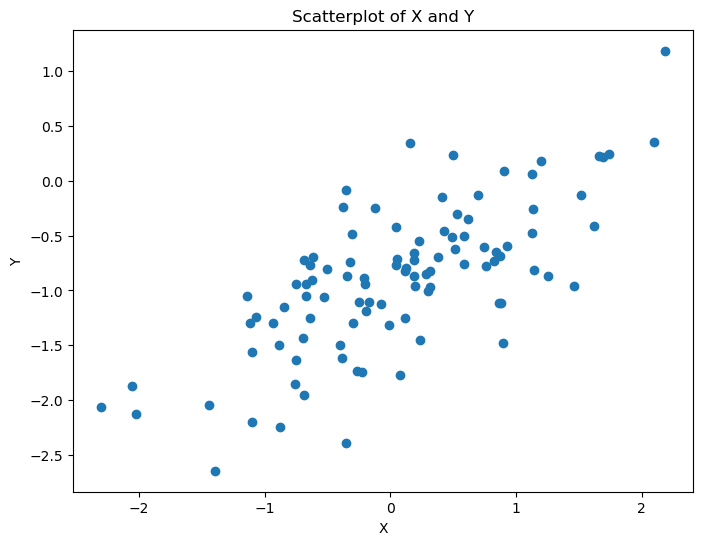

In [5]:
# (d) Create a scatterplot to see the relationship between x and y.

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Scatterplot of X and Y")

plt.show()

The scatterplot shows a positive(b1=0.5 & 0.5>0), approximately linear relationship between X and Y. As X increases, Y tends to increase. The points are not exactly on a straight line because of the random error term ϵ.

In [6]:
#(e) Fit a least squares linear regression

#Our model is:

#Y=β0+β1X+ϵ
# Add intercept
X = sm.add_constant(x)

# Fit least squares regression
model = sm.OLS(y, X).fit()

# Display results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     107.0
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           2.20e-17
Time:                        11:35:43   Log-Likelihood:                -65.124
No. Observations:                 100   AIC:                             134.2
Df Residuals:                      98   BIC:                             139.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9265      0.047    -19.717      0.0

In [7]:
#Get the estimated coefficient
print("Estimated Beta_0:", model.params[0])
print("Estimated Beta_1:", model.params[1])

Estimated Beta_0: -0.9264932351508992
Estimated Beta_1: 0.5477135668255859


In [8]:
#Compare the true model with our estimated model

#The true model was: Y=−1+0.5X+ϵ

#Our estimated model is: Y^ =−0.9265+0.5477X

print("Coefficient comparison")
print("----------------------")
print("              True       Estimated")
print(f"Beta_0       {-1:.4f}      {model.params[0]:.4f}")
print(f"Beta_1        {0.5:.4f}       {model.params[1]:.4f}")

Coefficient comparison
----------------------
              True       Estimated
Beta_0       -1.0000      -0.9265
Beta_1        0.5000       0.5477


The estimated coefficients are close to the true coefficients. The estimated intercept is approximately -0.9265 compared with the true value of -1, and the estimated slope is approximately 0.5477 compared with the true value of 0.5. The estimates are not exactly equal because the data contain random noise.

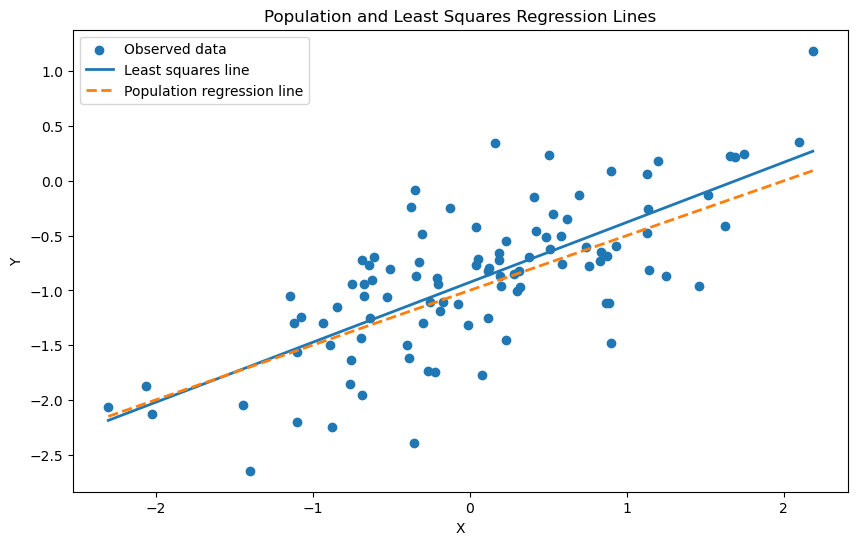

In [10]:
#(f) Plot both regression lines
#Population regression line Y=−1+0.5X Least squares regression line:Y^=−0.9265+0.5477X
# Create values of X for plotting the lines
x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

# Least squares regression line
y_hat = model.params[0] + model.params[1] * x_line

# Population regression line
y_population = -1 + 0.5 * x_line

#Let plot them
fig, ax = plt.subplots(figsize=(10, 6))

# Scatterplot
ax.scatter(
    x,
    y,
    label="Observed data"
)

# Least squares regression line
ax.plot(
    x_line,
    y_hat,
    linewidth=2,
    label="Least squares line"
)

# Population regression line
ax.plot(
    x_line,
    y_population,
    linestyle="--",
    linewidth=2,
    label="Population regression line"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Population and Least Squares Regression Lines")

ax.legend()

plt.show()

The least squares regression line is close to the population regression line. However, the two lines are not identical because the least squares line is estimated from the randomly generated sample, while the population regression line represents the true data-generating model.

In [11]:
#(g) Polynomial regression
#Now we add a quadratic term:X^2
#Our new model is:Y=β0+β1X+β2X^2+ϵ
#Let create X^2
x_squared = x ** 2

print(x_squared[:10])

[2.63849786 0.37424591 0.2789654  1.15126166 0.74893036 5.29708037
 3.04436809 0.57943595 0.10178594 0.06218558]


In [12]:
#Now let create the model 
# Create predictors X and X^2
X_poly = np.column_stack([
    x,
    x_squared
])

# Add intercept
X_poly = sm.add_constant(X_poly)

# Fit polynomial regression
poly_model = sm.OLS(
    y,
    X_poly
).fit()

# Display results
print(poly_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     52.96
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           2.83e-16
Time:                        11:47:14   Log-Likelihood:                -65.107
No. Observations:                 100   AIC:                             136.2
Df Residuals:                      97   BIC:                             144.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9325      0.058    -16.158      0.0

In [14]:
#check the quadratic term X^2 & P-VALUE
print("Coefficient for X^2:", poly_model.params[2])
print("P-value for X^2:", poly_model.pvalues[2])

Coefficient for X^2: 0.007711300469125812
P-value for X^2: 0.8564999985447295


The quadratic term is NOT statistically significant because 0.8565>0.05

In [15]:
#Let compare R^2
print("Linear model R-squared:",
      round(model.rsquared, 4))

print("Polynomial model R-squared:",
      round(poly_model.rsquared, 4))

Linear model R-squared: 0.5218
Polynomial model R-squared: 0.522


There is no evidence that the quadratic term improves the model. The p-value for X
2
 is approximately 0.8565, which is greater than 0.05. Also, the R-squared value increases only slightly from approximately 0.5218 to 0.5220. Therefore, the linear model is sufficient.

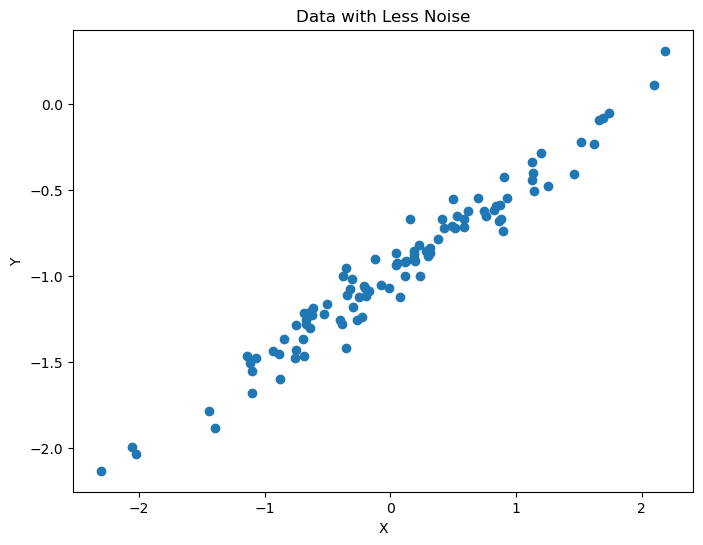

In [17]:
#(h) Repeat with less noise
# Now we reduce the variance of the error term.Originally:Var(ϵ)=0.25 We will use:Var(ϵ)=0.01 Therefore: SD= (0.01)*1/2 =0.1
#Step 1: Generate new data
# Set seed again
np.random.seed(1)

# Generate X
x_less_noise = np.random.normal(
    loc=0,
    scale=1,
    size=100
)

# Generate less noisy error
eps_less_noise = np.random.normal(
    loc=0,
    scale=np.sqrt(0.01),
    size=100
)

# Generate Y
y_less_noise = (
    -1
    + 0.5 * x_less_noise
    + eps_less_noise
)

#step2 :Plot Less-noisy data
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    x_less_noise,
    y_less_noise
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Data with Less Noise")

plt.show()

In [18]:
#Step 3:Fit Regression model
X_less_noise = sm.add_constant(
    x_less_noise
)

model_less_noise = sm.OLS(
    y_less_noise,
    X_less_noise
).fit()

print(model_less_noise.summary())

#Get coefficient 
print("Estimated Beta_0:",
      model_less_noise.params[0])

print("Estimated Beta_1:",
      model_less_noise.params[1])

print("R-squared:",
      model_less_noise.rsquared)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2314.
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           5.58e-70
Time:                        12:00:36   Log-Likelihood:                 95.820
No. Observations:                 100   AIC:                            -187.6
Df Residuals:                      98   BIC:                            -182.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9853      0.009   -104.844      0.0

In [19]:
#Step 4: Compare the original and less-noisy models
print("ORIGINAL MODEL")
print("----------------")
print("Beta_0 =", round(model.params[0], 4))
print("Beta_1 =", round(model.params[1], 4))
print("R-squared =", round(model.rsquared, 4))

print("\nLESS-NOISE MODEL")
print("----------------")
print("Beta_0 =", round(model_less_noise.params[0], 4))
print("Beta_1 =", round(model_less_noise.params[1], 4))
print("R-squared =", round(model_less_noise.rsquared, 4))

ORIGINAL MODEL
----------------
Beta_0 = -0.9265
Beta_1 = 0.5477
R-squared = 0.5218

LESS-NOISE MODEL
----------------
Beta_0 = -0.9853
Beta_1 = 0.5095
R-squared = 0.9594


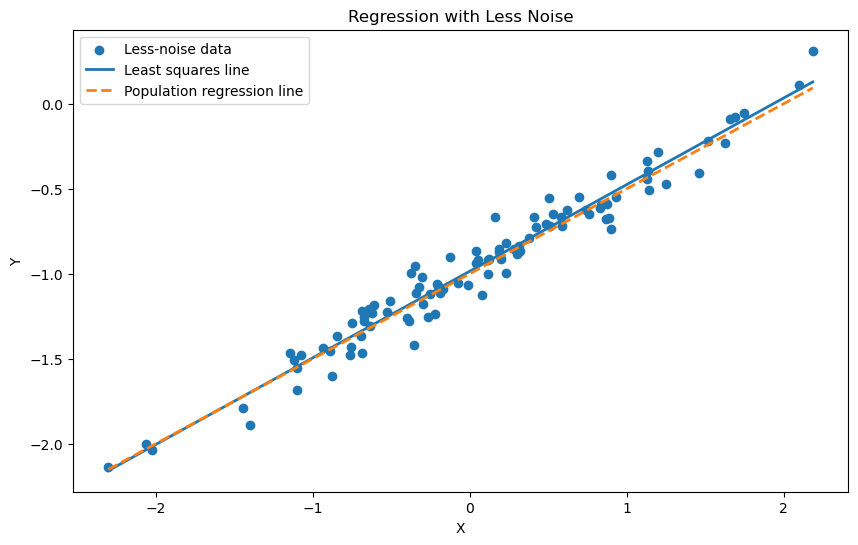

In [20]:
#Step 5: Plot the two lines for the less-noisy data

x_line = np.linspace(
    x_less_noise.min(),
    x_less_noise.max(),
    100
)

# Estimated regression line
y_hat_less_noise = (
    model_less_noise.params[0]
    + model_less_noise.params[1] * x_line
)

# True population line
y_population = -1 + 0.5 * x_line

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    x_less_noise,
    y_less_noise,
    label="Less-noise data"
)

ax.plot(
    x_line,
    y_hat_less_noise,
    linewidth=2,
    label="Least squares line"
)

ax.plot(
    x_line,
    y_population,
    linestyle="--",
    linewidth=2,
    label="Population regression line"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Regression with Less Noise")

ax.legend()

plt.show()

The estimates become much closer to the true values, and the observations lie much closer to the population regression line.

In [22]:
#(i) More noise in the data
#The question asks us to repeat (a)–(f) after increasing the variance of the error term.
#For more noise, we keep the same model:Y=−1+0.5X+ϵ but increase the variance of ϵ.
#The original was:ϵ∼N(0,0.25) Let's use: ϵ∼N(0,1) because this has more variance.


# Reset the random number generator
rng = np.random.default_rng(1)

# Generate X
x_more_noise = rng.normal(size=100)

print("Length of x:", len(x_more_noise))
# Generate epsilon with more noise
# Variance = 1, so standard deviation = 1

eps_more_noise = rng.normal(
    scale=1,
    size=100
)

print("Length of eps:", len(eps_more_noise))

# Generate Y
y_more_noise = -1 + 0.5 * x_more_noise + eps_more_noise

print("Length of y:", len(y_more_noise))

Length of x: 100
Length of eps: 100
Length of y: 100


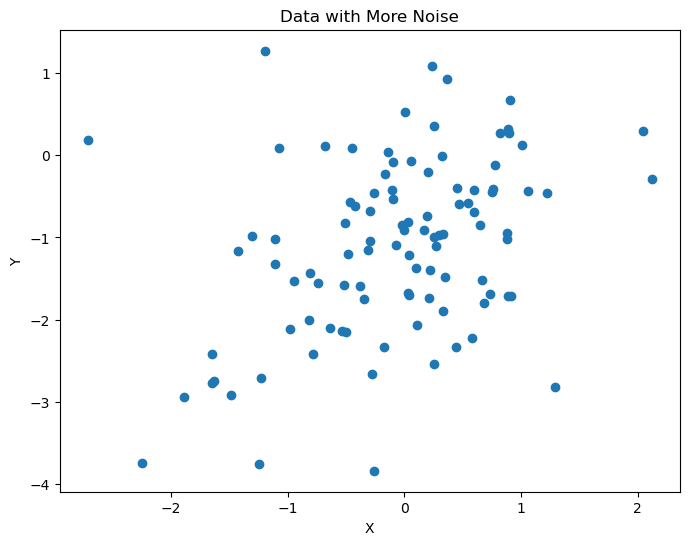

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    x_more_noise,
    y_more_noise
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Data with More Noise")

plt.show()

Compared with the original data, the points should be more widely scattered around the regression line.

The relationship is still positive because the true slope remains:

β1=0.5

But the relationship looks weaker because the error term is larger.

In [25]:
#Fit the regression model
# Add intercept
X_more_noise = sm.add_constant(x_more_noise)

# Fit model
model_more_noise = sm.OLS(
    y_more_noise,
    X_more_noise
).fit()

# Display results
print(model_more_noise.summary())

#CHECK COEFFICEITN 
print("Estimated Beta_0:",
      model_more_noise.params[0])

print("Estimated Beta_1:",
      model_more_noise.params[1])

print("R-squared:",
      model_more_noise.rsquared)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     15.87
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           0.000131
Time:                        14:39:23   Log-Likelihood:                -141.06
No. Observations:                 100   AIC:                             286.1
Df Residuals:                      98   BIC:                             291.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0760      0.101    -10.701      0.0

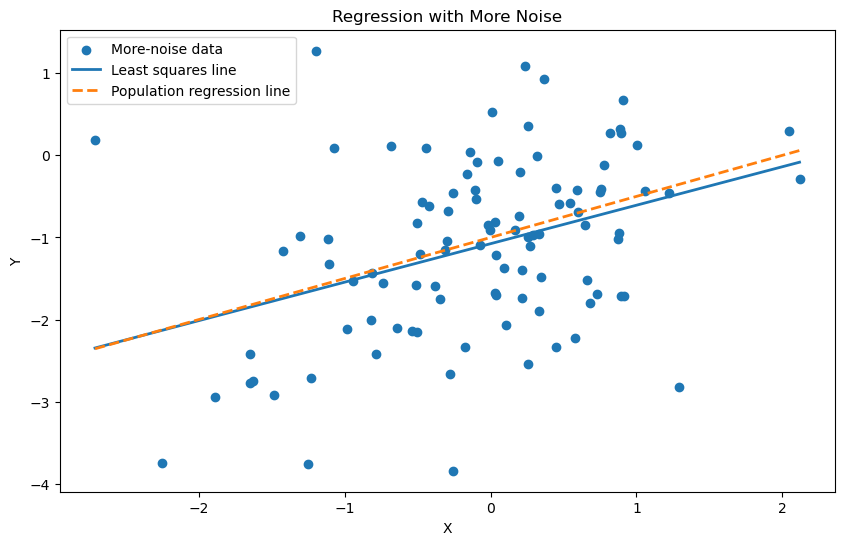

In [26]:
#pLOT REGRESSION LINE 
x_line = np.linspace(
    x_more_noise.min(),
    x_more_noise.max(),
    100
)

# Estimated regression line
y_hat_more_noise = (
    model_more_noise.params[0]
    + model_more_noise.params[1] * x_line
)

# True population line
y_population = -1 + 0.5 * x_line

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    x_more_noise,
    y_more_noise,
    label="More-noise data"
)

ax.plot(
    x_line,
    y_hat_more_noise,
    linewidth=2,
    label="Least squares line"
)

ax.plot(
    x_line,
    y_population,
    linestyle="--",
    linewidth=2,
    label="Population regression line"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Regression with More Noise")

ax.legend()

plt.show()

When the variance of the error term is increased from 0.25 to 1, there is more noise in the data. The observations become more widely scattered around the population regression line. The estimated coefficients are approximately 
β^0=−0.8530 and β^1=0.5954, compared with the true values of −1 and 0.5. The R-squared decreases to approximately 0.2438, showing that X explains less of the variation in Y. Thus, increasing the noise makes the linear relationship harder to detect and reduces the explanatory power of the model.

In [35]:
#(j) Confidence intervals

#Now we need to find the 95% confidence intervals for β0 and β1 for:
#Original data, Noisier data, Less noisy data
#This is a very important part because it demonstrates how noise affects the precision of our estimates.

print("95% Confidence Intervals")
print("=" * 70)

print("\nOriginal Data:")
print(model.conf_int())

print("\nLess Noisy Data:")
print(model_less_noise.conf_int())

print("\nNoisier Data:")
print(model_more_noise.conf_int())

95% Confidence Intervals

Original Data:
[[-1.01974096 -0.83324551]
 [ 0.44261338  0.65281376]]

Less Noisy Data:
[[-1.00394819 -0.9666491 ]
 [ 0.48852268  0.53056275]]

Noisier Data:
[[-1.27556397 -0.87648714]
 [ 0.23513073  0.70203333]]


The confidence intervals become narrower when there is less noise and wider when there is more noise. With less noise, the observations are closer to the true regression line, resulting in more precise estimates of β0 and β1 With more noise, there is greater variability around the regression line, which increases the standard errors and therefore produces wider confidence intervals. The original data fall between the two cases. This demonstrates that reducing the error variance improves the precision of the estimated regression coefficients.